In [22]:
# Cài đặt các thư viện cần thiết cho cả 2 tác vụ
!pip install -q transformers datasets evaluate seqeval underthesea

In [71]:
# Tải và giải nén dữ liệu ACSC (UIT-ViSFD) từ GitHub
import os
import zipfile

if not os.path.exists('/content/data/UIT-ViSFD'):
    print("Đang tải tập dữ liệu UIT-ViSFD...")
    !git clone https://github.com/LuongPhan/UIT-ViSFD /tmp/visfd_repo

    # Tìm file zip trong repo và giải nén
    zip_path = '/tmp/visfd_repo/UIT-ViSFD.zip'
    if os.path.exists(zip_path):
        os.makedirs('/content/data/UIT-ViSFD', exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('/content/data/UIT-ViSFD')
        print("✅ Đã giải nén dữ liệu vào /content/data/UIT-ViSFD/")
    else:
        print("❌ Không tìm thấy file UIT-ViSFD.zip trong repository.")
else:
    print("Dữ liệu đã tồn tại.")

Đang tải tập dữ liệu UIT-ViSFD...
fatal: destination path '/tmp/visfd_repo' already exists and is not an empty directory.
✅ Đã giải nén dữ liệu vào /content/data/UIT-ViSFD/


In [23]:
import os
# Clone the dataset repository
!git clone https://github.com/kimkim00/UIT-ViSD4SA.git /content/uit_visd4sa_repo

# Create the expected directory structure for ATE
os.makedirs('/content/data/UIT-ViSD4SA', exist_ok=True)

# Fix: Correct paths to files inside the 'data' folder of the repository
!cp /content/uit_visd4sa_repo/data/train.jsonl /content/data/UIT-ViSD4SA/
!cp /content/uit_visd4sa_repo/data/dev.jsonl /content/data/UIT-ViSD4SA/
!cp /content/uit_visd4sa_repo/data/test.jsonl /content/data/UIT-ViSD4SA/

print("Dataset cloned and moved successfully to /content/data/UIT-ViSD4SA/")

fatal: destination path '/content/uit_visd4sa_repo' already exists and is not an empty directory.
Dataset cloned and moved successfully to /content/data/UIT-ViSD4SA/


In [24]:
import os, re, json, glob, random, unicodedata, inspect, shutil
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split as sk_split

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, AutoModel,
    DataCollatorForTokenClassification, TrainingArguments, Trainer
)
from transformers.modeling_outputs import ModelOutput
from datasets import Dataset as HFDataset
from underthesea import word_tokenize
import evaluate

In [26]:
#Cấu hình chung
MODEL_NAME = 'vinai/phobert-base-v2'
MAX_LENGTH = 256
SEED = 42

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Thiết bị đang sử dụng:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Thiết bị đang sử dụng: cuda
GPU: Tesla T4


In [27]:
# Tải Tokenizer chung
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print('Fast tokenizer?', tokenizer.is_fast)

Fast tokenizer? False


##HUẤN LUYỆN MÔ HÌNH ATE (Trích xuất từ khóa)

###Xử lý dữ liệu ATE

In [28]:
# Cấu hình ATE
ATE_LABEL_LIST = ['O', 'B-ASPECT', 'I-ASPECT']
ATE_ID2LABEL = {i: l for i, l in enumerate(ATE_LABEL_LIST)}
ATE_LABEL2ID = {l: i for i, l in enumerate(ATE_LABEL_LIST)}

In [29]:
def clean_text_safe(text):
    return unicodedata.normalize('NFC', text)

In [30]:
def vietnamese_word_segment(text):
    return word_tokenize(text, format='text')

In [31]:
def _build_char_map(orig, seg):
    char_map = [-1] * len(orig)
    i, j = 0, 0
    while i < len(orig) and j < len(seg):
        if orig[i] == seg[j]:
            char_map[i] = j; i += 1; j += 1
        elif seg[j] == '_':
            j += 1
        elif orig[i].isspace():
            i += 1
        elif seg[j].isspace():
            j += 1
        else:
            i += 1
    return char_map

In [32]:
def align_spans_after_segmentation(text, labels):
    segmented = vietnamese_word_segment(text)
    char_map = _build_char_map(text, segmented)
    new_labels = []
    for start, end, lab in labels:
        new_start = -1
        for k in range(start, min(end, len(text))):
            if 0 <= k < len(char_map) and char_map[k] != -1:
                new_start = char_map[k]; break
        if new_start == -1: continue
        new_end = new_start + 1
        for k in range(end - 1, start - 1, -1):
            if 0 <= k < len(char_map) and char_map[k] != -1:
                new_end = char_map[k] + 1; break
        while new_end < len(segmented) and segmented[new_end] == '_':
            new_end += 1
            while new_end < len(segmented) and not segmented[new_end].isspace():
                new_end += 1
        new_labels.append([new_start, new_end, lab])
    return segmented, new_labels

In [33]:
def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line: data.append(json.loads(line))
    return data

In [34]:
def preprocess_visd4sa(raw_data):
    out = []
    for item in raw_data:
        text = clean_text_safe(item['text'])
        labels = item.get('labels', [])
        text, labels = align_spans_after_segmentation(text, labels)
        out.append({'text': text, 'labels': labels})
    return out

In [35]:
# Đọc dữ liệu ATE
try:
    raw_train_ate = load_jsonl('/content/data/UIT-ViSD4SA/train.jsonl')
    raw_eval_ate = load_jsonl('/content/data/UIT-ViSD4SA/dev.jsonl')

    train_data_ate = preprocess_visd4sa(raw_train_ate)
    eval_data_ate = preprocess_visd4sa(raw_eval_ate)
    print(f'Tải dữ liệu ATE thành công: train={len(train_data_ate)}, eval={len(eval_data_ate)}')
except Exception as e:
    print("Lỗi tải dữ liệu ATE. Hãy kiểm tra lại thư mục /content/data/UIT-ViSD4SA/. Chi tiết:", e)

Tải dữ liệu ATE thành công: train=7785, eval=1112


###Sinh BIO Tags và Dataset ATE

In [36]:
def get_word_offsets(text):
    offsets = []
    pos = 0
    for w in text.split():
        idx = text.find(w, pos)
        offsets.append((idx, idx + len(w)))
        pos = idx + len(w)
    return offsets

In [37]:
def create_ate_bio_tags(example, tokenizer=tokenizer, max_length=MAX_LENGTH):
    text = example['text']
    labels = example['labels']
    words = text.split()
    word_offsets = get_word_offsets(text)

    word_tags = [0] * len(words)
    for start_char, end_char, _ in labels:
        first = True
        for wi, (ws, we) in enumerate(word_offsets):
            if ws < end_char and we > start_char:
                word_tags[wi] = 1 if first else 2
                first = False

    input_ids = [tokenizer.cls_token_id]
    bio_tags = [-100]
    attention_mask = [1]

    for word, tag in zip(words, word_tags):
        sub_ids = tokenizer.encode(word, add_special_tokens=False)
        if not sub_ids: continue
        if len(input_ids) + len(sub_ids) + 1 > max_length: break
        input_ids.extend(sub_ids)
        bio_tags.append(tag)
        bio_tags.extend([-100] * (len(sub_ids) - 1))
        attention_mask.extend([1] * len(sub_ids))

    input_ids.append(tokenizer.sep_token_id)
    bio_tags.append(-100)
    attention_mask.append(1)

    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': bio_tags}

In [38]:
train_encoded_ate = [create_ate_bio_tags(it) for it in train_data_ate]
eval_encoded_ate = [create_ate_bio_tags(it) for it in eval_data_ate]

train_ds_ate = HFDataset.from_list(train_encoded_ate)
eval_ds_ate = HFDataset.from_list(eval_encoded_ate)

In [39]:
# Tính class weights
def compute_class_weights(dataset, num_labels):
    counts = Counter()
    for item in dataset:
        for lab in item['labels']:
            if lab != -100: counts[lab] += 1
    total = sum(counts.values())
    weights = [(total / (num_labels * counts.get(i, 1))) ** 0.5 for i in range(num_labels)]
    return torch.tensor(weights, dtype=torch.float)

class_weights_ate = compute_class_weights(train_ds_ate, num_labels=3)

###Huấn luyện ATE

In [40]:
class WeightedTokenTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        weights = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=weights, ignore_index=-100)
        loss = loss_fct(logits.view(-1, logits.shape[-1]), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [41]:
seqeval = evaluate.load('seqeval')

In [42]:
def compute_metrics_ate(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [[ATE_LABEL_LIST[pp] for (pp, ll) in zip(pred, lab) if ll != -100] for pred, lab in zip(predictions, labels)]
    true_labels = [[ATE_LABEL_LIST[ll] for (pp, ll) in zip(pred, lab) if ll != -100] for pred, lab in zip(predictions, labels)]
    results = seqeval.compute(predictions=true_predictions, references=true_labels, zero_division=0)
    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
        'accuracy': results['overall_accuracy'],
    }

In [43]:
OUTPUT_DIR_ATE = '/content/ate_training'
FINAL_CHECKPOINT_ATE = '/content/ate_checkpoint'
os.makedirs(FINAL_CHECKPOINT_ATE, exist_ok=True)

In [44]:
model_ate = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ATE_ID2LABEL, label2id=ATE_LABEL2ID
)

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [45]:
training_args_ate = TrainingArguments(
    output_dir=OUTPUT_DIR_ATE,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    logging_steps=50,
    report_to='none',
    seed=SEED,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [46]:
data_collator_ate = DataCollatorForTokenClassification(tokenizer=tokenizer)
_trainer_params = inspect.signature(Trainer.__init__).parameters
_tok_kwarg = 'processing_class' if 'processing_class' in _trainer_params else 'tokenizer'

In [47]:
trainer_ate = WeightedTokenTrainer(
    class_weights=class_weights_ate,
    model=model_ate,
    args=training_args_ate,
    train_dataset=train_ds_ate,
    eval_dataset=eval_ds_ate,
    data_collator=data_collator_ate,
    compute_metrics=compute_metrics_ate,
    **{_tok_kwarg: tokenizer}
)

In [48]:
  # Bắt đầu huấn luyện ATE
trainer_ate.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.505445,0.481392,0.421960,0.567950,0.484190,0.803701
2,0.448904,0.438700,0.520056,0.631370,0.570332,0.823806
3,0.342903,0.457151,0.527145,0.635051,0.576088,0.821118
4,0.276594,0.479401,0.512809,0.646093,0.571787,0.823651
5,0.219024,0.560325,0.532076,0.655153,0.587235,0.821403
6,0.167424,0.573424,0.546901,0.652039,0.594860,0.824013
7,0.145652,0.639856,0.566931,0.647508,0.604547,0.824116
8,0.124205,0.648912,0.561282,0.644394,0.599974,0.824762
9,0.093030,0.689054,0.565476,0.645527,0.602856,0.824840
10,0.098776,0.685074,0.567231,0.644960,0.603604,0.824788


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4870, training_loss=0.25575182792831985, metrics={'train_runtime': 844.1203, 'train_samples_per_second': 92.226, 'train_steps_per_second': 5.769, 'total_flos': 3735425033243964.0, 'train_loss': 0.25575182792831985, 'epoch': 10.0})

In [49]:
# Lưu trọng số
torch.save(model_ate.state_dict(), os.path.join(FINAL_CHECKPOINT_ATE, 'best.pt'))
if os.path.exists(OUTPUT_DIR_ATE): shutil.rmtree(OUTPUT_DIR_ATE)

###biểu đồ đánh giá mô hình ATE

In [50]:
history_ate = trainer_ate.state.log_history
epochs_train_ate, train_loss_ate = [], []
epochs_eval_ate, eval_loss_ate, eval_f1_ate, eval_acc_ate = [], [], [], []

In [51]:
for log in history_ate:
    if 'loss' in log and 'epoch' in log:
        epochs_train_ate.append(log['epoch'])
        train_loss_ate.append(log['loss'])
    elif 'eval_loss' in log and 'epoch' in log:
        epochs_eval_ate.append(log['epoch'])
        eval_loss_ate.append(log['eval_loss'])
        eval_f1_ate.append(log['eval_f1'])
        eval_acc_ate.append(log['eval_accuracy'])

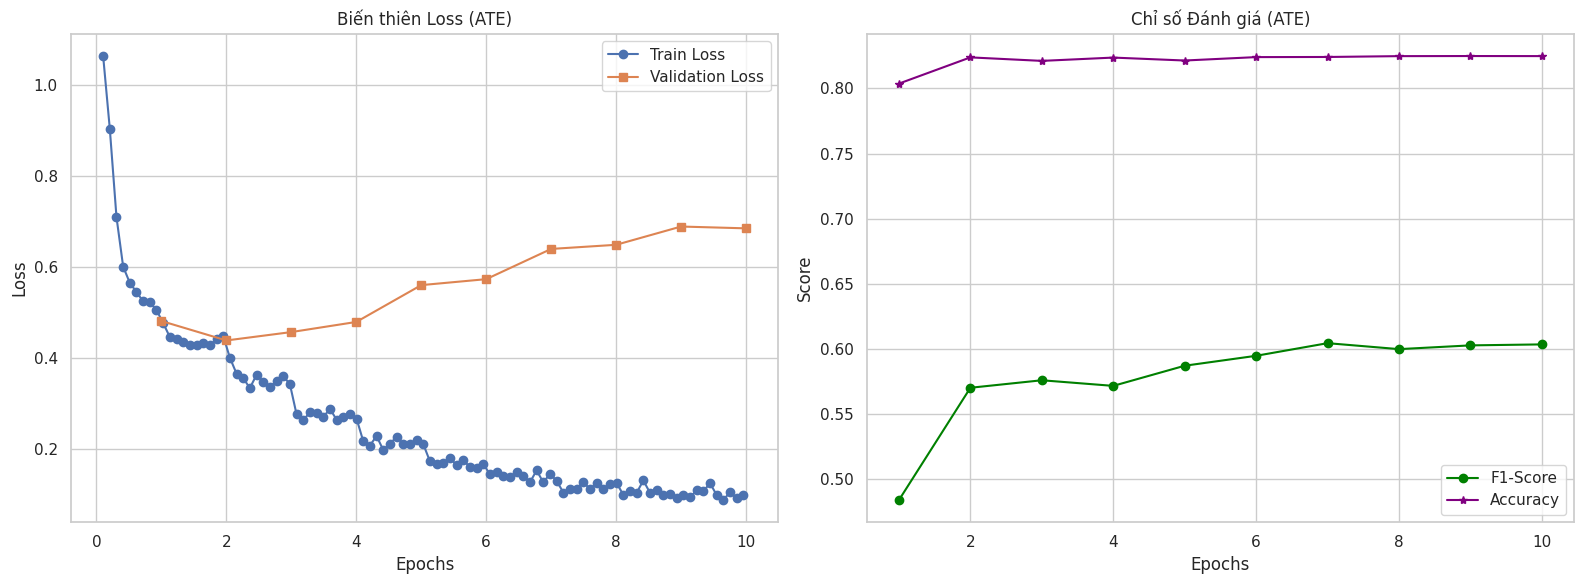

In [52]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(epochs_train_ate, train_loss_ate, label='Train Loss', marker='o')
ax[0].plot(epochs_eval_ate, eval_loss_ate, label='Validation Loss', marker='s')
ax[0].set_title('Biến thiên Loss (ATE)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(epochs_eval_ate, eval_f1_ate, label='F1-Score', marker='o', color='green')
ax[1].plot(epochs_eval_ate, eval_acc_ate, label='Accuracy', marker='*', color='purple')
ax[1].set_title('Chỉ số Đánh giá (ATE)')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Score')
ax[1].legend()

plt.tight_layout()
ate_metrics_path = '/content/ate_metrics.png'
plt.savefig(ate_metrics_path, dpi=300)
plt.show()

In [55]:
# Đánh giá Confusion Matrix ATE trên tập Dev
predictions_ate, labels_ate, _ = trainer_ate.predict(eval_ds_ate)
preds_ate = np.argmax(predictions_ate, axis=2)

y_true_ate, y_pred_ate = [], []

In [56]:
for pred_row, lab_row in zip(preds_ate, labels_ate):
    for p, l in zip(pred_row, lab_row):
        if l != -100:
            y_true_ate.append(ATE_LABEL_LIST[l])
            y_pred_ate.append(ATE_LABEL_LIST[int(p)])

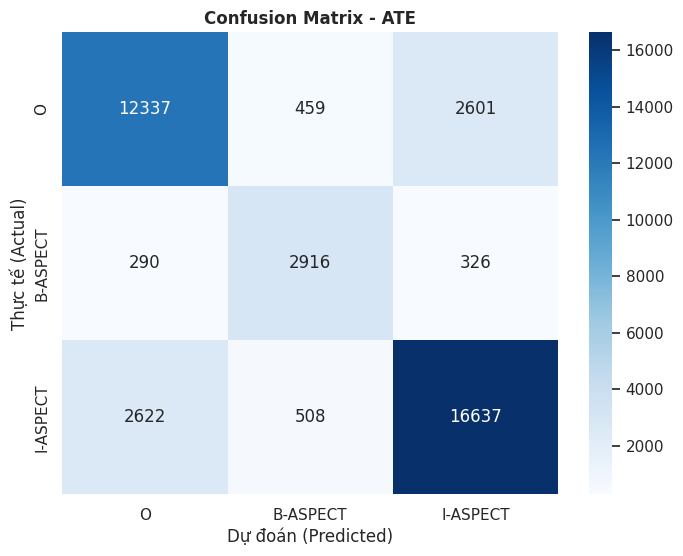

In [57]:
cm_ate = confusion_matrix(y_true_ate, y_pred_ate, labels=ATE_LABEL_LIST)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ate, annot=True, fmt='d', cmap='Blues', xticklabels=ATE_LABEL_LIST, yticklabels=ATE_LABEL_LIST)
plt.title('Confusion Matrix - ATE', fontweight='bold')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
ate_cm_path = '/content/ate_cm.png'
plt.savefig(ate_cm_path, dpi=300)
plt.show()

##HUẤN LUYỆN MÔ HÌNH ACSC (Phân loại khía cạnh & Cảm xúc)

###Tiền xử lý dữ liệu ACSC

In [58]:
ASPECT_LIST = [
    'SCREEN', 'CAMERA', 'FEATURES', 'BATTERY', 'PERFORMANCE',
    'STORAGE', 'DESIGN', 'PRICE', 'GENERAL', 'SER&ACC',
]

In [59]:
NUM_ASPECTS = len(ASPECT_LIST)
NUM_SENTIMENTS = 4
SENTIMENT_MAP = {0: 'None', 1: 'Positive', 2: 'Neutral', 3: 'Negative'}

In [60]:
TEENCODE_MAP = {
    'ko': 'không', 'k': 'không', 'kh': 'không', 'khong': 'không',
    'đc': 'được', 'dc': 'được', 'duoc': 'được',
    'vs': 'với', 'ng': 'người', 'j': 'gì', 'z': 'vậy', 'v': 'vậy',
    'trc': 'trước', 'mk': 'mình', 'm': 'mình', 't': 'tôi',
    'ok': 'tốt', 'oke': 'tốt', 'sp': 'sản phẩm', 'shp': 'shop',
    'tks': 'cảm ơn', 'rep': 'trả lời', 'vcl': 'rất', 'vl': 'rất',
}
_EMOJI_RE = re.compile(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251]+', flags=re.UNICODE)

In [61]:
def clean_text_acsc(text: str) -> str:
    text = unicodedata.normalize('NFC', str(text))
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = _EMOJI_RE.sub(' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = ' '.join(TEENCODE_MAP.get(w.lower(), w) for w in text.split())
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [62]:
def parse_visfd_labels(label_str, aspect_list=ASPECT_LIST):
    labels = [0] * len(aspect_list)
    if not isinstance(label_str, str) or not label_str.strip(): return labels
    sent_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3}
    for pair in label_str.split(';'):
        pair = pair.strip().strip('{}')
        if '#' not in pair: continue
        aspect, sent = pair.split('#', 1)
        aspect = aspect.strip().upper()
        sent = sent.strip().capitalize()
        if aspect in aspect_list:
            labels[aspect_list.index(aspect)] = sent_map.get(sent, 0)
    return labels


In [72]:
# Tìm dataset ACSC (UIT-ViSFD)
# Tìm tất cả file .csv trong thư mục dữ liệu
all_csvs = glob.glob('/content/data/UIT-ViSFD/*.csv')

if not all_csvs:
    print("Không tìm thấy CSV cho UIT-ViSFD. Vui lòng chạy lại ô tải dữ liệu ở trên.")
else:
    dfs = [pd.read_csv(p) for p in all_csvs]
    df_full = pd.concat(dfs, ignore_index=True)

    # Tiền xử lý dữ liệu
    df_full['clean_text'] = df_full['comment'].astype(str).apply(clean_text_acsc)
    df_full['segmented'] = df_full['clean_text'].apply(vietnamese_word_segment)
    df_full['labels'] = df_full['label'].apply(parse_visfd_labels)

    # Loại bỏ dòng trống sau khi tokenize
    df_full = df_full[df_full['segmented'].str.len() > 0].reset_index(drop=True)

    # Chia tập dữ liệu
    train_df_acsc, test_df_acsc = sk_split(df_full, test_size=0.15, random_state=SEED)
    train_df_acsc = train_df_acsc.reset_index(drop=True)
    test_df_acsc = test_df_acsc.reset_index(drop=True)

    print(f"✅ Tải dữ liệu ACSC thành công!")
    print(f"- Tổng số mẫu: {len(df_full)}")
    print(f"- Tập Train: {len(train_df_acsc)}")
    print(f"- Tập Test: {len(test_df_acsc)}")

✅ Tải dữ liệu ACSC thành công!
- Tổng số mẫu: 11122
- Tập Train: 9453
- Tập Test: 1669


###Dataset và Class Weights ACSC

In [73]:
# Tắt Data Augmentation trong code mẫu để tránh code quá dài, sử dụng bản gốc nếu bạn đã có sẵn hàm augment_minority_classes
class ACSCDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        self.texts  = df['segmented'].tolist()
        self.labels = df['labels'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [74]:
train_ds_acsc = ACSCDataset(train_df_acsc, tokenizer)
test_ds_acsc  = ACSCDataset(test_df_acsc,  tokenizer)

In [75]:
# Tính class weights cho ACSC
all_labels_flat = []
for labs in train_df_acsc['labels']:
    all_labels_flat.extend(labs)

In [76]:
class_counts = Counter(all_labels_flat)
total = sum(class_counts.values())

In [77]:
class_weights_acsc = torch.tensor([
    (total / (NUM_SENTIMENTS * class_counts.get(i, 1))) ** 0.5
    for i in range(NUM_SENTIMENTS)
], dtype=torch.float)

###Model MultiTaskACSC và Huấn luyện

In [78]:
from dataclasses import dataclass

In [87]:
from typing import Optional

@dataclass
class ACSCOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None

In [94]:
class MultiTaskACSC(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_aspects=NUM_ASPECTS, num_sentiments=NUM_SENTIMENTS, dropout=0.3, class_weights=None):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.num_aspects = num_aspects
        self.num_sentiments = num_sentiments
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        self.classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden // 2, num_sentiments),
            ) for _ in range(num_aspects)
        ])

        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        logits = torch.stack([clf(cls) for clf in self.classifiers], dim=1)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = 0.0
            for i in range(self.num_aspects):
                loss = loss + loss_fct(logits[:, i, :], labels[:, i])
            loss = loss / self.num_aspects

        return ACSCOutput(loss=loss, logits=logits)

In [95]:
def compute_metrics_acsc(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    results = {}
    per_aspect_f1 = []
    for i, aspect in enumerate(ASPECT_LIST):
        yt, yp = labels[:, i], preds[:, i]
        f1  = f1_score(yt, yp, average='macro', zero_division=0)
        acc = accuracy_score(yt, yp)
        results[f'{aspect}_f1']  = float(f1)
        results[f'{aspect}_acc'] = float(acc)
        per_aspect_f1.append(f1)

    results['macro_f1'] = float(np.mean(per_aspect_f1))
    results['overall_acc'] = float((preds == labels).mean())
    return results

In [96]:
OUTPUT_DIR_ACSC = '/content/acsc_training'
FINAL_CHECKPOINT_ACSC = '/content/acsc_checkpoint'
os.makedirs(FINAL_CHECKPOINT_ACSC, exist_ok=True)

In [97]:
model_acsc = MultiTaskACSC(class_weights=class_weights_acsc)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [98]:
training_args_acsc = TrainingArguments(
    output_dir=OUTPUT_DIR_ACSC,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    logging_steps=50,
    report_to='none',
    seed=SEED,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [99]:
trainer_acsc = Trainer(
    model=model_acsc,
    args=training_args_acsc,
    train_dataset=train_ds_acsc,
    eval_dataset=test_ds_acsc,
    compute_metrics=compute_metrics_acsc,
    **{_tok_kwarg: tokenizer}
)

In [100]:
# Bắt đầu huấn luyện ACSC
trainer_acsc.train()

Epoch,Training Loss,Validation Loss,Screen F1,Screen Acc,Camera F1,Camera Acc,Features F1,Features Acc,Battery F1,Battery Acc,Performance F1,Performance Acc,Storage F1,Storage Acc,Design F1,Design Acc,Price F1,Price Acc,General F1,General Acc,Ser&acc F1,Ser&acc Acc,Macro F1,Overall Acc
1,0.974603,0.868245,0.234066,0.880168,0.368069,0.766926,0.325871,0.618334,0.377879,0.547633,0.335314,0.471540,0.248493,0.988017,0.276490,0.825644,0.305437,0.659676,0.320246,0.545836,0.363526,0.777711,0.315539,0.708149
2,0.724661,0.670509,0.402224,0.902337,0.605013,0.844817,0.416659,0.624326,0.579572,0.778310,0.424636,0.556621,0.248493,0.988017,0.342999,0.837627,0.454492,0.859796,0.408191,0.606351,0.515642,0.872978,0.439792,0.787118
3,0.571622,0.532366,0.545855,0.920911,0.728270,0.922109,0.535852,0.789694,0.643671,0.865189,0.458900,0.597364,0.248493,0.988017,0.494061,0.914919,0.591784,0.875374,0.460325,0.650689,0.609170,0.904733,0.531638,0.842900
4,0.489583,0.461749,0.598675,0.939485,0.766997,0.934092,0.627573,0.871180,0.668871,0.887358,0.534375,0.685440,0.248493,0.988017,0.575138,0.935291,0.633218,0.881965,0.513608,0.685440,0.602040,0.899940,0.576899,0.870821
5,0.410152,0.424694,0.623715,0.949670,0.795520,0.944877,0.636464,0.883164,0.703097,0.898742,0.578409,0.729778,0.325566,0.989215,0.585871,0.937687,0.748707,0.912522,0.554344,0.718394,0.603508,0.901738,0.615520,0.886579
6,0.379877,0.398995,0.634715,0.952666,0.803838,0.941881,0.650595,0.882564,0.745742,0.907130,0.617321,0.742361,0.325566,0.989215,0.607496,0.944278,0.766297,0.914919,0.610442,0.734572,0.615300,0.910725,0.637731,0.892031
7,0.354362,0.393222,0.631139,0.952067,0.805818,0.943080,0.655838,0.884961,0.757820,0.910725,0.612142,0.748951,0.325566,0.989215,0.610402,0.943679,0.756053,0.912522,0.616026,0.734572,0.611049,0.907729,0.638185,0.892750
8,0.351208,0.391813,0.634567,0.952666,0.804667,0.942481,0.651835,0.884362,0.763846,0.912522,0.612265,0.748951,0.408974,0.989814,0.615009,0.944877,0.767229,0.914919,0.609858,0.733373,0.610633,0.906531,0.647888,0.893050


TrainOutput(global_step=2368, training_loss=0.5689884782642931, metrics={'train_runtime': 1567.7837, 'train_samples_per_second': 48.236, 'train_steps_per_second': 1.51, 'total_flos': 0.0, 'train_loss': 0.5689884782642931, 'epoch': 8.0})

In [101]:
# Lưu trọng số ACSC
torch.save(model_acsc.state_dict(), os.path.join(FINAL_CHECKPOINT_ACSC, 'best.pt'))
torch.save(class_weights_acsc, os.path.join(FINAL_CHECKPOINT_ACSC, 'class_weights.pt'))
if os.path.exists(OUTPUT_DIR_ACSC): shutil.rmtree(OUTPUT_DIR_ACSC)

###biểu đồ đánh giá mô hình ACSC

In [102]:
history_acsc = trainer_acsc.state.log_history
epochs_train_acsc, train_loss_acsc = [], []
epochs_eval_acsc, eval_loss_acsc, eval_macro_f1 = [], [], []

In [103]:
for log in history_acsc:
    if 'loss' in log and 'epoch' in log:
        epochs_train_acsc.append(log['epoch'])
        train_loss_acsc.append(log['loss'])
    elif 'eval_loss' in log and 'epoch' in log:
        epochs_eval_acsc.append(log['epoch'])
        eval_loss_acsc.append(log['eval_loss'])
        eval_macro_f1.append(log['eval_macro_f1'])



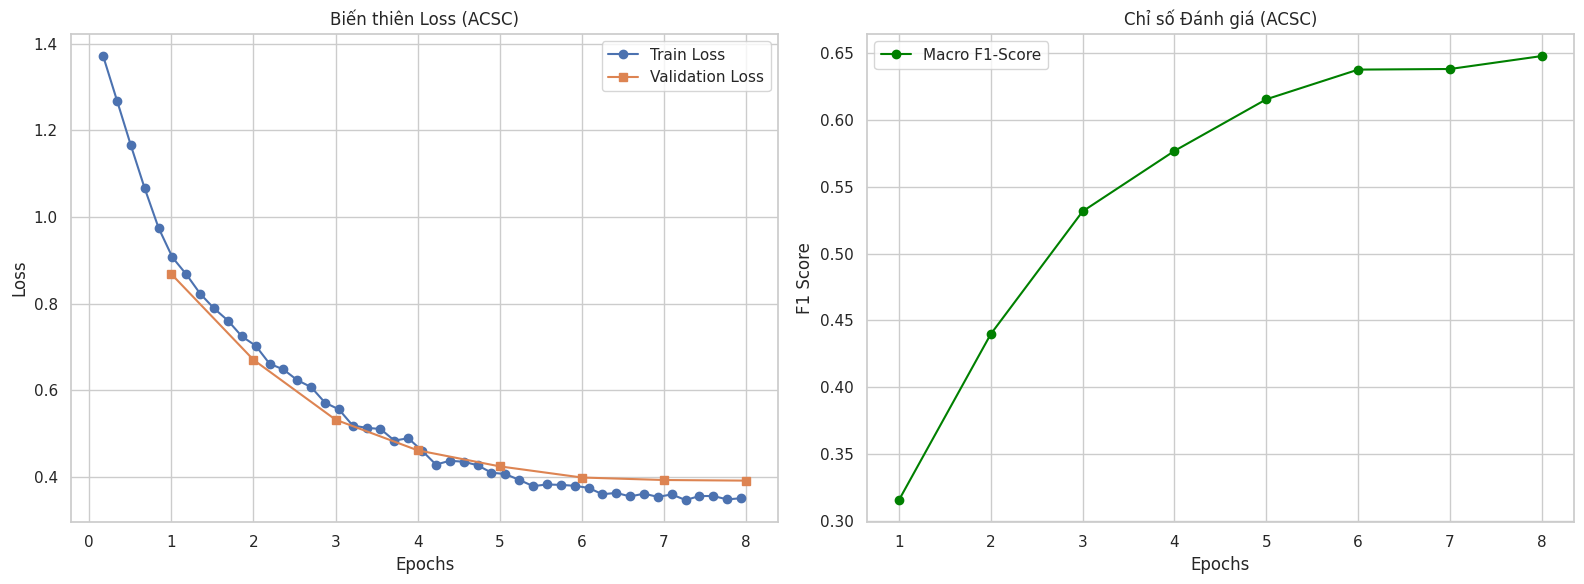

In [104]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].plot(epochs_train_acsc, train_loss_acsc, label='Train Loss', marker='o')
ax[0].plot(epochs_eval_acsc, eval_loss_acsc, label='Validation Loss', marker='s')
ax[0].set_title('Biến thiên Loss (ACSC)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(epochs_eval_acsc, eval_macro_f1, label='Macro F1-Score', marker='o', color='green')
ax[1].set_title('Chỉ số Đánh giá (ACSC)')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('F1 Score')
ax[1].legend()

plt.tight_layout()
acsc_metrics_path = '/content/acsc_metrics.png'
plt.savefig(acsc_metrics_path, dpi=300)
plt.show()

In [105]:
# Đánh giá F1 per aspect trên tập Test
model_acsc.eval().to(DEVICE)
test_loader = DataLoader(test_ds_acsc, batch_size=64, shuffle=False)

all_preds_acsc, all_labels_acsc = [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        attn = batch['attention_mask'].to(DEVICE)
        logits = model_acsc(input_ids=ids, attention_mask=attn).logits
        all_preds_acsc.append(logits.argmax(-1).cpu().numpy())
        all_labels_acsc.append(batch['labels'].numpy())

all_preds_acsc = np.concatenate(all_preds_acsc)
all_labels_acsc = np.concatenate(all_labels_acsc)

/tmp/ipykernel_5463/536531098.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ASPECT_LIST, y=per_aspect_f1, palette="viridis")


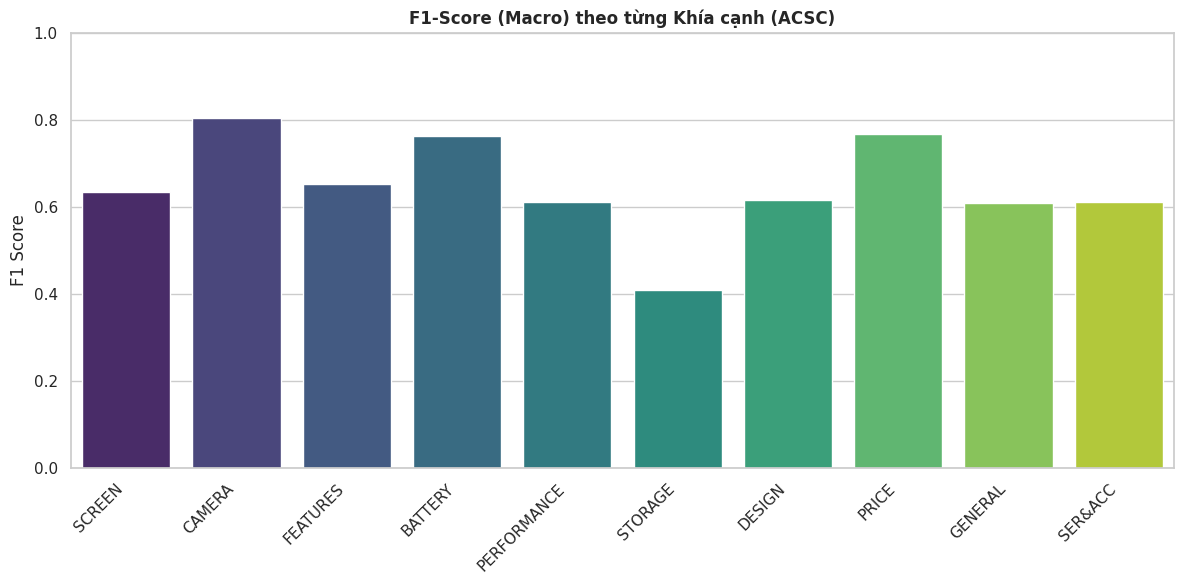

In [106]:
per_aspect_f1 = []
for i, a in enumerate(ASPECT_LIST):
    yt, yp = all_labels_acsc[:, i], all_preds_acsc[:, i]
    f1 = f1_score(yt, yp, average='macro', zero_division=0)
    per_aspect_f1.append(f1)

plt.figure(figsize=(12, 6))
sns.barplot(x=ASPECT_LIST, y=per_aspect_f1, palette="viridis")
plt.title('F1-Score (Macro) theo từng Khía cạnh (ACSC)', fontweight='bold')
plt.ylim(0, 1.0)
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1 Score')
acsc_aspect_f1_path = '/content/acsc_aspect_f1.png'
plt.tight_layout()
plt.savefig(acsc_aspect_f1_path, dpi=300)
plt.show()

## ĐÓNG GÓI ZIP

###Nén toàn bộ trọng số và biểu đồ

In [107]:
import os
import shutil

export_dir = "/content/export_pipeline2"
checkpoints_dir = os.path.join(export_dir, "checkpoints/two_stage")
outputs_dir = os.path.join(export_dir, "outputs/pipeline2")

os.makedirs(checkpoints_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

# 1. Copy trọng số ATE
if os.path.exists("/content/ate_checkpoint/best.pt"):
    shutil.copy("/content/ate_checkpoint/best.pt", os.path.join(checkpoints_dir, "ate_best.pt"))

# 2. Copy trọng số ACSC và Class Weights
if os.path.exists("/content/acsc_checkpoint/best.pt"):
    shutil.copy("/content/acsc_checkpoint/best.pt", os.path.join(checkpoints_dir, "acsc_best.pt"))
if os.path.exists("/content/acsc_checkpoint/class_weights.pt"):
    shutil.copy("/content/acsc_checkpoint/class_weights.pt", os.path.join(checkpoints_dir, "acsc_class_weights.pt"))

# 3. Copy toàn bộ biểu đồ
images = [
    "/content/ate_metrics.png",
    "/content/ate_cm.png",
    "/content/acsc_metrics.png",
    "/content/acsc_aspect_f1.png"
]

for img in images:
    if os.path.exists(img):
        shutil.copy(img, outputs_dir)

# 4. Nén Zip để tải về
shutil.make_archive("/content/pipeline2_export", "zip", export_dir)

# Dọn dẹp
shutil.rmtree(export_dir)

print("✅ Đã tạo file zip thành công tại /content/pipeline2_export.zip")
print("Hãy tải file này về và giải nén (Extract Here) tại thư mục gốc của project ở local.")

✅ Đã tạo file zip thành công tại /content/pipeline2_export.zip
Hãy tải file này về và giải nén (Extract Here) tại thư mục gốc của project ở local.
